In [41]:
import numpy as np
from sim_library.constants import k_eff, dR, m, kb, omega_eg
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq, RR3_adjMDFE_500kHz
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare
from sim_library.data_io import load_p_dists

In [50]:
def evolve_free(dt: float, state_vec: np.ndarray, delta_D: float, delta_R: float, delta_L: float, basis: np.ndarray):
    new_state_vec = np.zeros_like(state_vec)
    for i, n in enumerate(basis):
        if n % 2 == 0:
            new_state_vec[i] = state_vec[i]*np.exp(1j*n*(delta_D+(n*delta_R))*dt)
        else:
            new_state_vec[i] = state_vec[i]*np.exp(1j*(n*(delta_D+(n*delta_R))-delta_L)*dt)
    return new_state_vec

In [ ]:
def evolve_uppulse(dt: float, state_vec: np.ndarray, omega_R: float, phi_L: float, delta_D: float, delta_R: float, delta_L: float, basis: np.ndarray):
    new_state_vec = np.zeros_like(state_vec)
    start = 0
    end = len(basis)-1
    if basis[0] % 2 == 1:
        new_state_vec[0] = state_vec[0]*np.exp(1j*(basis[0]*(delta_D+(basis[0]*delta_R))-delta_L)*dt)
        start = 1
    if basis[-1] % 2 == 0:
        new_state_vec[-1] = state_vec[-1]*np.exp(1j*(basis[-1]*(delta_D+(basis[-1]*delta_R)))*dt)
    for i in range(start,end,2):
        n = basis[i]
        delta_p = delta_D + (2*n+1)*delta_R - delta_L
        omega_eff = np.sqrt((omega_R**2)+(delta_p**2))
        P = np.exp(1j*(n*(delta_D+(n*delta_R))+(delta_p/2))*dt)
        C = np.cos(omega_eff*dt/2)-(1j*(delta_p/omega_eff)*np.sin(omega_eff*dt/2))
        C_conj = np.cos(omega_eff*dt/2)+(1j*(delta_p/omega_eff)*np.sin(omega_eff*dt/2))
        S = np.exp(1j*phi_L)*(omega_R/omega_eff)*np.sin(omega_eff*dt/2)
        S_conj = np.exp(-1j*phi_L)*(omega_R/omega_eff)*np.sin(omega_eff*dt/2)
        new_state_vec[i] = P*((C*state_vec[i])-(1j*S_conj*state_vec[i+1]))
        new_state_vec[i+1] = P*((C_conj*state_vec[i+1])-(1j*S*state_vec[i]))

    return new_state_vec


In [15]:
def evolve_downpulse(dt: float, state_vec: np.ndarray, omega_R: float, phi_L: float, delta_D: float, delta_R: float, delta_L: float, basis: np.ndarray):
    new_state_vec = np.zeros_like(state_vec)
    start = 0
    end = len(basis)-1
    if basis[0] % 2 == 0:
        new_state_vec[0] = state_vec[0]*np.exp(1j*(basis[0]*(delta_D+(basis[0]*delta_R)))*dt)
        start = 1
    if basis[-1] % 2 == 1:
        new_state_vec[-1] = state_vec[-1]*np.exp(1j*(basis[-1]*(delta_D+(basis[-1]*delta_R))-delta_L)*dt)
    for i in range(start,end,2):
        n = basis[i]
        delta_p = delta_D + (2*n+1)*delta_R - delta_L
        delta_m = delta_D + (2*n+1)*delta_R + delta_L
        omega_eff = np.sqrt((omega_R**2)+(delta_m**2))
        P = np.exp(1j*(n*(delta_D+(n*delta_R))+(delta_p/2))*dt)
        C = np.cos(omega_eff*dt/2)-(1j*(delta_m/omega_eff)*np.sin(omega_eff*dt/2))
        C_conj = np.cos(omega_eff*dt/2)+(1j*(delta_m/omega_eff)*np.sin(omega_eff*dt/2))
        S = np.exp(-1j*phi_L)*(omega_R/omega_eff)*np.sin(omega_eff*dt/2)
        S_conj = np.exp(1j*phi_L)*(omega_R/omega_eff)*np.sin(omega_eff*dt/2)
        new_state_vec[i] = P*((C*state_vec[i])-(1j*S_conj*state_vec[i+1]))
        new_state_vec[i+1] = P*((C_conj*state_vec[i+1])-(1j*S*state_vec[i]))

    return new_state_vec


In [4]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 10

indices = [9,10]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 0
initial_state[indices[1]] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0 # Stationary

pulse_seq = RR3_gate(rabi_freq=rabi_freq, time_steps=n_steps)

wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)
# print(wave_func[:,indices[0]:indices[1]+1])

# print((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi)/pi)

display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])


+---------+---------------------+---------------+----------------------+-------------------+-----------------+
|   Index |   Momentum (hbar*k) |   Initial Psi |            Final Psi |   Initial |Psi|^2 |   Final |Psi|^2 |
+=========+=====================+===============+======================+===================+=================+
|       0 |                  -8 |       0j|000> |         (-0+0j)|000> |                 0 |           0     |
+---------+---------------------+---------------+----------------------+-------------------+-----------------+
|       1 |                  -7 |       0j|001> |              0j|001> |                 0 |           0     |
+---------+---------------------+---------------+----------------------+-------------------+-----------------+
|       2 |                  -6 |       0j|010> |         (-0+0j)|010> |                 0 |           0     |
+---------+---------------------+---------------+----------------------+-------------------+-----------------+
|

In [23]:
# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e8
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 10

indices = [9,10]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 0
initial_state[indices[1]] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0 # Stationary

pulse_seq2 = RR3_adjMDFE_500kHz(time_steps=n_steps)

wave_func, times = simulate_pulses_single_atom(pulse_seq=pulse_seq2, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)
# print(wave_func[:,indices[0]:indices[1]+1])

# print((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi)/pi)

display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])



+---------+---------------------+---------------+----------------------+-------------------+-----------------+
|   Index |   Momentum (hbar*k) |   Initial Psi |            Final Psi |   Initial |Psi|^2 |   Final |Psi|^2 |
+=========+=====================+===============+======================+===================+=================+
|       0 |                  -8 |       0j|000> |              0j|000> |                 0 |           0     |
+---------+---------------------+---------------+----------------------+-------------------+-----------------+
|       1 |                  -7 |       0j|001> |             -0j|001> |                 0 |           0     |
+---------+---------------------+---------------+----------------------+-------------------+-----------------+
|       2 |                  -6 |       0j|010> |              0j|010> |                 0 |           0     |
+---------+---------------------+---------------+----------------------+-------------------+-----------------+
|

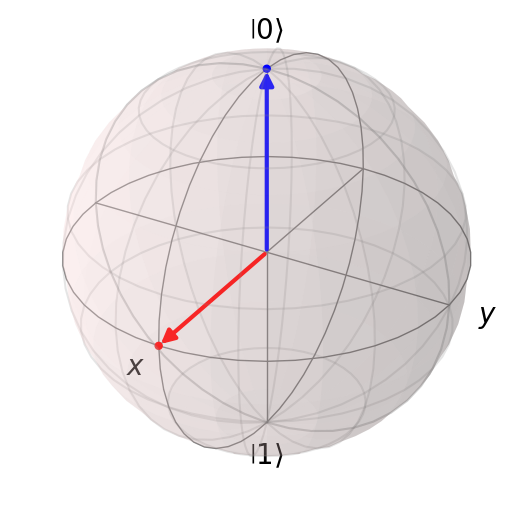

[0. 2.]


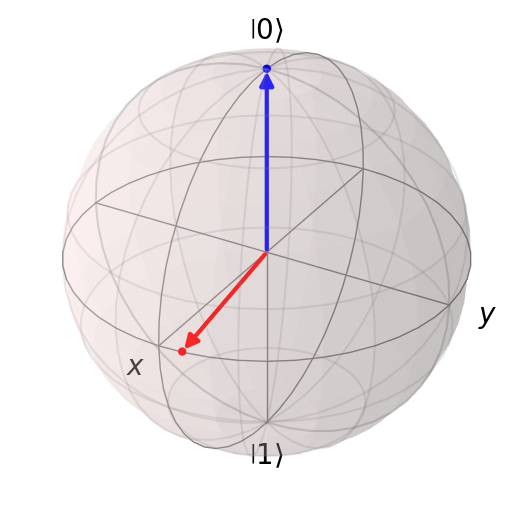

[0.         0.03928551]


In [122]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,9]
indices2 = [10,11]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[1]] = 0
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0.0 # Stationary

MDFE = gen_MDFEdown_seq(free_time=pi/(2*dR), rabi_freq=rabi_freq, time_steps=n_steps)

pulse_seq1 = PulseSequence()
pulse2 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq*1e0), duration=rabi_time/(1e0*4))
pulse3 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq*1e0), duration=rabi_time/(1e0*4))
pulse1 = DownPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time)
detuning = omega_eg
free_time = 2*pi/detuning
free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=free_time/2)
pulse_seq1.add_pulses([pulse3])



wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)
plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)
print((np.angle(wave_func[:,indices[1]]) - np.angle(wave_func[:,indices[0]])) % (2*np.pi)/pi)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices2[0]] = 1
initial_state[indices2[1]] = 0
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)
plot_bloch(wave_func=wave_func[:,indices2[0]:indices2[1]+1], show=True)
print((np.angle(wave_func[:,indices2[1]]) - np.angle(wave_func[:,indices2[0]])) % (2*np.pi)/pi)




# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])


In [123]:
print(dR)

97003.8447164657


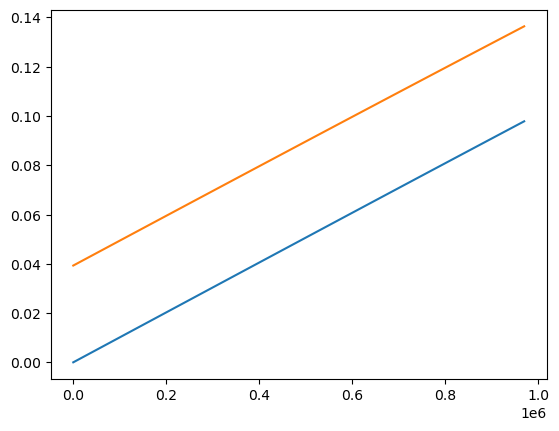

In [99]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,9]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[0]+2] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0.0000 # Stationary

MDFE = gen_MDFEdown_seq(free_time=pi/(2*dR), rabi_freq=rabi_freq, time_steps=n_steps)

pulse_seq1 = PulseSequence()
pulse2 = UpPulse(laser_det=np.full(n_steps,dR-detuning),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq*1e0), duration=rabi_time/(1e0*4))

pulse_seq1.add_pulses([pulse3])

detunings = np.linspace(0, 10*dR, 100)
angles = np.zeros((2,len(detunings)))

for i, det in enumerate(detunings):
    pulse_seq1 = PulseSequence()
    pulse2 = UpPulse(laser_det=np.full(n_steps,dR-det),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/(4))
    pulse_seq1.add_pulses([pulse2])
    wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)
    angles[0,i] = (np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]]))
    angles[1,i] = (np.angle(wave_func[-1,indices[1]+2]) - np.angle(wave_func[-1,indices[0]+2]))



plt.plot(detunings,angles[0,:]/pi)
plt.plot(detunings,angles[1,:]/pi)
# plt.ylim(0,0.5)
# print(wave_func[:,indices[0]:indices[1]+1])

# print((np.angle(wave_func[:,indices[1]]) - np.angle(wave_func[:,indices[0]])) % (2*np.pi)/pi)

# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
